In [13]:
import anndata
import pandas as pd
from scipy import sparse
import h5py
from pathlib import Path
import squidpy as sq
import scanpy as sc
import mygene
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
currentpath   = Path.cwd()
filepath      = currentpath / "A1/outs/binned_outputs/square_008um/filtered_feature_bc_matrix.h5"
clusterspath  = currentpath / "A1/outs/binned_outputs/square_008um/analysis/clustering/gene_expression_graphclust/clusters.csv"
positionspath = currentpath / "A1/outs/binned_outputs/square_008um/spatial/tissue_positions.parquet"
differential_expression_path = currentpath / "A1" / "outs" / "binned_outputs" / "square_008um" / "analysis" / "diffexp" / "gene_expression_graphclust" / "differential_expression.csv"


# 1. Load matrix + barcodes
with h5py.File(filepath, "r") as f:
    data     = f["matrix/data"][:]
    indices  = f["matrix/indices"][:]
    indptr   = f["matrix/indptr"][:]
    shape    = f["matrix/shape"][:]
    barcodes = f["matrix/barcodes"][:].astype(str)
    genes    = f["matrix/features/name"][:].astype(str)

X = sparse.csc_matrix((data, indices, indptr), shape=shape)   # genes x spots

# 2. Load clusters and get the set of clustered barcodes
clustersdf = pd.read_csv(clusterspath)              # Barcode,Cluster
clustersdf = clustersdf.rename(columns={"Barcode": "barcode"})
cluster_bcs = clustersdf["barcode"].astype(str)

# 3. Find the indices in the matrix that correspond to clustered barcodes
bc_to_idx = {bc: i for i, bc in enumerate(barcodes)}
valid_idx = [bc_to_idx[bc] for bc in cluster_bcs if bc in bc_to_idx]

print("found", len(valid_idx), "clustered barcodes in matrix")

# 4. Subset matrix to those columns and create AnnData
X_sub = X[:, valid_idx]                             # genes x clustered_spots
adata = anndata.AnnData(X=X_sub.T)                  # cells x genes

# align names
adata.obs_names = cluster_bcs.tolist()              # same order as clustersdf
adata.var_names = genes

# 5. Attach clusters (now aligned by order)
adata.obs["Cluster"] = clustersdf["Cluster"].values.astype(int)

# 6. Map to cell types
cluster_to_ct = {
    1: "Ovarian.cancer.cell",
    2: "Fibroblast",
    3: "Unknown",
    4: "Myeloid.cell",
    5: "Endothelial.cell",
}
adata.obs["cell_type"] = adata.obs["Cluster"].map(cluster_to_ct).astype("category")

print(adata.obs["cell_type"].value_counts())

found 161641 clustered barcodes in matrix
cell_type
Ovarian.cancer.cell    50843
Fibroblast             49712
Unknown                36776
Myeloid.cell           21400
Endothelial.cell        2910
Name: count, dtype: int64


In [3]:
# optional: add spatial coords for these barcodes
positionsdf = pd.read_parquet(positionspath)
positionsdf = positionsdf.set_index("barcode")
coords = positionsdf.loc[adata.obs_names, ["pxl_row_in_fullres", "pxl_col_in_fullres"]].to_numpy()
adata.obsm["spatial"] = coords

In [5]:
# Keep only in-tissue spots
pos = positionsdf[positionsdf["in_tissue"] == 1].copy()

# Merge cluster labels onto positions
pos = pos.merge(clustersdf, on="barcode", how="inner")
# pos now has: in_tissue, array_row, array_col, pxl_row_in_fullres,
#              pxl_col_in_fullres, barcode, Cluster


In [8]:
# Determine grid size
n_rows = pos["array_row"].max() + 1
n_cols = pos["array_col"].max() + 1

# Initialize grid with -1 = empty
cluster_grid = np.full((n_rows, n_cols), fill_value=-1, dtype=int)

# Fill with cluster IDs
for _, r in pos.iterrows():
    i = int(r["array_row"])
    j = int(r["array_col"])
    cluster_grid[i, j] = int(r["Cluster"])

In [47]:
cluster_to_ct = {
    1: "Ovarian.cancer.cell",
    2: "Fibroblast",
    3: "Unknown",
    4: "Myeloid.cell",
    5: "Endothelial.cell",
}
n_types = len(cluster_to_ct)

def neighbor_counts(cluster_grid, radius=1, n_types=5):
    n_rows, n_cols = cluster_grid.shape
    counts = np.zeros((n_rows, n_cols, n_types), dtype=int)
    
    for i in range(n_rows):
        for j in range(n_cols):
            center_type = cluster_grid[i, j]
            if center_type == -1:
                continue
            for di in range(-radius, radius + 1):
                for dj in range(-radius, radius + 1):
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < n_rows and 0 <= nj < n_cols:
                        t = cluster_grid[ni, nj]
                        if t != -1:
                            counts[i, j, t - 1] += 1
    return counts

radius = 1   # can tune
neighbor_counts_arr = neighbor_counts(cluster_grid, radius=radius, n_types=n_types)

# Convert to fractions per bin
total_neighbors = neighbor_counts_arr.sum(axis=-1, keepdims=True).clip(min=1)
neighbor_fracs_arr = neighbor_counts_arr / total_neighbors

In [48]:
interaction = np.zeros((n_types, n_types), dtype=float)  # focal x neighbor
focal_counts = np.zeros(n_types, dtype=int)

n_rows, n_cols = cluster_grid.shape
for i in range(n_rows):
    for j in range(n_cols):
        focal_type = cluster_grid[i, j]
        if focal_type == -1:
            continue
        f_idx = focal_type - 1
        interaction[f_idx, :] += neighbor_fracs_arr[i, j, :]
        focal_counts[f_idx] += 1

# Average across bins of each focal type
for t in range(n_types):
    if focal_counts[t] > 0:
        interaction[t, :] /= focal_counts[t]

In [49]:
labels = [cluster_to_ct[k] for k in range(1, n_types + 1)]

interaction_df = pd.DataFrame(
    interaction,
    index=labels,   # focal bin type
    columns=labels  # neighbor type
)
interaction_df

,Ovarian.cancer.cell,Fibroblast,Unknown,Myeloid.cell,Endothelial.cell
Ovarian.cancer.cell,0.869784,0.083934,0.020180,0.021390,0.004711
Fibroblast,0.085855,0.725309,0.094942,0.078421,0.015473
Unknown,0.028430,0.129069,0.758841,0.071165,0.006133
Myeloid.cell,0.050802,0.182179,0.120318,0.638028,0.008673
Endothelial.cell,0.082372,0.264380,0.077341,0.063841,0.512065


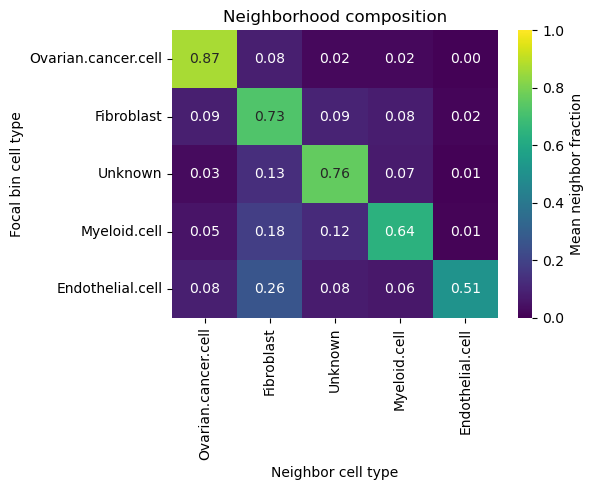

In [51]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    interaction_df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Mean neighbor fraction"}
)
plt.xlabel("Neighbor cell type")
plt.ylabel("Focal bin cell type")
plt.title(f"Neighborhood composition")
plt.tight_layout()
plt.show()

In [30]:
cluster_to_ct = {
    1: "Ovarian.cancer.cell",
    2: "Fibroblast",
    3: "Unknown",
    4: "Myeloid.cell",
    5: "Endothelial.cell",
}
n_types = len(cluster_to_ct)


def neighbor_counts(cluster_grid, radius=1, n_types=5):
    n_rows, n_cols = cluster_grid.shape
    counts = np.zeros((n_rows, n_cols, n_types), dtype=int)
    
    for i in range(n_rows):
        for j in range(n_cols):
            center_type = cluster_grid[i, j]
            if center_type == -1:
                continue
            for di in range(-radius, radius + 1):
                for dj in range(-radius, radius + 1):
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < n_rows and 0 <= nj < n_cols:
                        t = cluster_grid[ni, nj]
                        if t != -1:
                            counts[i, j, t - 1] += 1
    return counts


radius = 1   # can tune
neighbor_counts_arr = neighbor_counts(cluster_grid, radius=radius, n_types=n_types)

# Fractions per bin
total_neighbors = neighbor_counts_arr.sum(axis=-1, keepdims=True).clip(min=1)
neighbor_fracs_arr = neighbor_counts_arr / total_neighbors

In [31]:
n_rows, n_cols = cluster_grid.shape

contour_mask = np.zeros((n_rows, n_cols), dtype=bool)

for i in range(n_rows):
    for j in range(n_cols):
        center_type = cluster_grid[i, j]
        if center_type == -1:
            continue

        tot = total_neighbors[i, j, 0]
        if tot == 0:
            continue

        same = neighbor_counts_arr[i, j, center_type - 1]
        diff = tot - same

        # criterion: at least half neighbors are different types
        if diff >= 0.5 * tot:
            contour_mask[i, j] = True

In [32]:
interaction = np.zeros((n_types, n_types), dtype=float)  # focal x neighbor
focal_counts = np.zeros(n_types, dtype=int)

for i in range(n_rows):
    for j in range(n_cols):
        if not contour_mask[i, j]:
            continue

        focal_type = cluster_grid[i, j]
        if focal_type == -1:
            continue

        f_idx = focal_type - 1
        # use neighbor_fracs_arr here, already normalized
        interaction[f_idx, :] += neighbor_fracs_arr[i, j, :]
        focal_counts[f_idx] += 1

for t in range(n_types):
    if focal_counts[t] > 0:
        interaction[t, :] /= focal_counts[t]

In [33]:
labels = [cluster_to_ct[k] for k in range(1, n_types + 1)]
interaction_df = pd.DataFrame(interaction, index=labels, columns=labels)

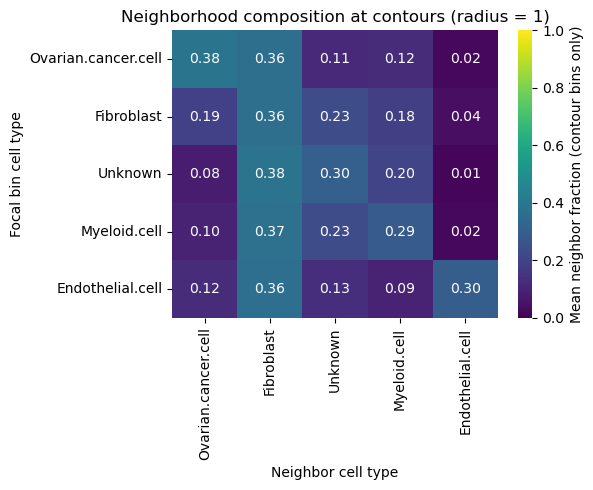

In [34]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    interaction_df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Mean neighbor fraction (contour bins only)"}
)
plt.xlabel("Neighbor cell type")
plt.ylabel("Focal bin cell type")
plt.title(f"Neighborhood composition at contours (radius = {radius})")
plt.tight_layout()
plt.show()

In [35]:
cluster_to_ct = {
    1: "Ovarian.cancer.cell",
    2: "Fibroblast",
    3: "Unknown",
    4: "Myeloid.cell",
    5: "Endothelial.cell",
}
n_types = len(cluster_to_ct)


def neighbor_counts(cluster_grid, radius=1, n_types=5):
    n_rows, n_cols = cluster_grid.shape
    counts = np.zeros((n_rows, n_cols, n_types), dtype=int)
    
    for i in range(n_rows):
        for j in range(n_cols):
            center_type = cluster_grid[i, j]
            if center_type == -1:
                continue
            for di in range(-radius, radius + 1):
                for dj in range(-radius, radius + 1):
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < n_rows and 0 <= nj < n_cols:
                        t = cluster_grid[ni, nj]
                        if t != -1:
                            counts[i, j, t - 1] += 1
    return counts


radius = 1   # can tune
neighbor_counts_arr = neighbor_counts(cluster_grid, radius=radius, n_types=n_types)

# Fractions per bin
total_neighbors = neighbor_counts_arr.sum(axis=-1, keepdims=True).clip(min=1)
neighbor_fracs_arr = neighbor_counts_arr / total_neighbors

In [36]:
# 1) Per-bin total, same-type, different-type counts
total_counts = neighbor_counts_arr.sum(axis=-1)  # shape (n_rows, n_cols)
same_type_counts = np.zeros((n_rows, n_cols), dtype=int)

for i in range(n_rows):
    for j in range(n_cols):
        center_type = cluster_grid[i, j]
        if center_type == -1:
            continue
        same_type_counts[i, j] = neighbor_counts_arr[i, j, center_type - 1]

diff_type_counts = total_counts - same_type_counts

In [46]:
# 2) Explore thresholds to see how many bins are "contour"
valid_bins = (cluster_grid != -1)

for thr in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    mask = (    
        (total_counts > 0) &
        (diff_type_counts >= thr * total_counts) &
        valid_bins
    )
    frac = mask.sum() / valid_bins.sum()
    print(f"thr={thr}: {frac:.2%} of bins are contour")

thr=0.2: 43.84% of bins are contour
thr=0.3: 33.08% of bins are contour
thr=0.4: 23.07% of bins are contour
thr=0.5: 22.90% of bins are contour
thr=0.6: 14.69% of bins are contour
thr=0.7: 8.89% of bins are contour
thr=0.8: 4.99% of bins are contour


In [42]:
thr = 0.8  # choose based on the diagnostics above
contour_mask = (
    (total_counts > 0) &
    (diff_type_counts >= thr * total_counts) &
    valid_bins
)

In [43]:
interaction = np.zeros((n_types, n_types), dtype=float)
focal_counts = np.zeros(n_types, dtype=int)

for i in range(n_rows):
    for j in range(n_cols):
        if not contour_mask[i, j]:
            continue

        focal_type = cluster_grid[i, j]
        if focal_type == -1:
            continue

        f_idx = focal_type - 1
        interaction[f_idx, :] += neighbor_fracs_arr[i, j, :]
        focal_counts[f_idx] += 1

for t in range(n_types):
    if focal_counts[t] > 0:
        interaction[t, :] /= focal_counts[t]

In [44]:
labels = [cluster_to_ct[k] for k in range(1, n_types + 1)]
interaction_df = pd.DataFrame(interaction, index=labels, columns=labels)

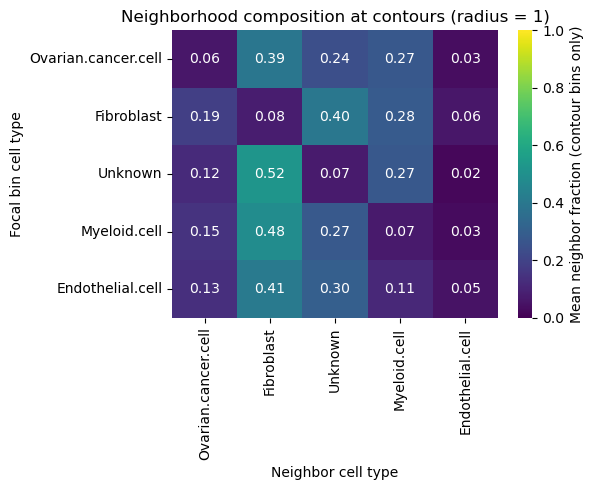

In [45]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    interaction_df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Mean neighbor fraction (contour bins only)"}
)
plt.xlabel("Neighbor cell type")
plt.ylabel("Focal bin cell type")
plt.title(f"Neighborhood composition at contours (radius = {radius})")
plt.tight_layout()
plt.show()

### Neighborhood enrichment analysis with Squidpy

We next quantified how different **cell types co-localize in space** using Squidpy’s neighborhood enrichment workflow. This uses the spatial coordinates stored in `adata.obsm["spatial"]` and the discrete cell-type labels in `adata.obs["cell_type"]`.

```python
import squidpy as sq

# 1. Build a spatial neighbors graph
sq.gr.spatial_neighbors(adata, coord_type="generic")
```

`sq.gr.spatial_neighbors` constructs a **k-nearest-neighbor graph in physical space** between spots/cells based on their 2D coordinates. The resulting adjacency matrices are stored in `adata.obsp["spatial_connectivities"]` and `adata.obsp["spatial_distances"]` and are then used for all downstream spatial statistics. 

```python
# 2. Compute neighborhood enrichment between cell types
sq.gr.nhood_enrichment(adata, cluster_key="cell_type")
```

`sq.gr.nhood_enrichment` uses this spatial graph and the `cell_type` annotation to test **which pairs of cell types are found as neighbors more (or less) often than expected by chance**. It performs a permutation-based test and stores for each cell-type pair a **z-score** and **interaction count** in `adata.uns["cell_type_nhood_enrichment"]`. Positive z-scores indicate enriched co-localization, negative scores indicate spatial avoidance.

```python
# 3. Visualize the enrichment matrix
sq.pl.nhood_enrichment(adata, cluster_key="cell_type")
```

`sq.pl.nhood_enrichment` plots the resulting **cell–cell interaction matrix** as a heatmap, where rows and columns correspond to cell types and colors encode the enrichment z-score. This provides an intuitive summary of the **tumor microenvironment structure**, highlighting, for example, which cell types form compact clusters (strong self-enrichment) and which preferentially neighbor ovarian cancer cells (high off-diagonal enrichment). 

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [00:19<00:00, 51.44/s]


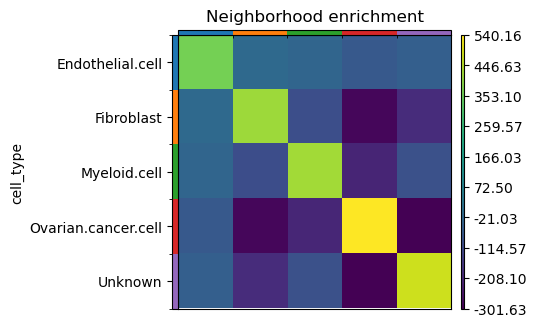

In [8]:
import squidpy as sq
sq.gr.spatial_neighbors(adata, coord_type="generic")
sq.gr.nhood_enrichment(adata, cluster_key="cell_type")
sq.pl.nhood_enrichment(adata, cluster_key="cell_type")

Ovarian.cancer.cell ↔ Ovarian.cancer.cell: very strong self‑enrichment (bright yellow) → tumor cells are spatially clustered (solid tumor islands).

Fibroblast ↔ Fibroblast, Myeloid.cell ↔ Myeloid.cell, Unknown ↔ Unknown: clear self‑enrichment → each forms its own niches.

Ovarian.cancer.cell with Fibroblast / Myeloid.cell: values look slightly negative to neutral → immune/stromal cells are more at the periphery of tumor clusters rather than perfectly mixed.

Endothelial.cell with others: mostly mild/neutral enrichment → vessels are relatively dispersed, not strongly co‑localized with a specific compartment.

In [3]:
keep = adata.obs["cell_type"].isin(
    ["Ovarian.cancer.cell", "Fibroblast", "Myeloid.cell"]
)
adata_sub = adata[keep].copy()
# optional further downsample for testing:
# sc.pp.subsample(adata_sub, n_obs=30000, random_state=0)

c:\Users\tesni\miniconda3\envs\ovarian-st\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


### Co-occurrence analysis of tumor, fibroblast, and myeloid niches

To quantify how **cell types co-occur as a function of spatial distance**, we computed Squidpy’s co-occurrence score on a downsampled subset of the data. This avoids the heavy memory/runtime cost of running the statistic on all spots while still capturing representative spatial patterns.


**Logic and statistic.**  
`sq.gr.co_occurrence` estimates, for each pair of cell types A (exp) and B (cond), the **co-occurrence ratio** as a function of radius *r*:  

$$
\text{co-occurrence}(A|B, r) = \frac{P(A \text{ within distance } r \mid B)}{P(A \text{ within distance } r)}
$$

- $P(A \mid B)$ is the conditional probability of finding $A$ within radius $r$ around $B$.  
- $P(A)$ is the global probability of $A$ within radius $r$ in the tissue.  
- Values **> 1** indicate that $A$ is enriched around $B$ at that distance; values **< 1** indicate spatial avoidance. 

**Expected output.**  
`sq.pl.co_occurrence` produces a line plot where:

- The **x-axis** is distance from each reference cell type (e.g., 0–200–400–… µm).  
- The **y-axis** is the **co-occurrence ratio**.  
- Each line shows how much a given **cell_type A** tends to be found near **cell_type B** as radius increases (often plotted for one “conditioning” cell type at a time).

In our context, these curves allow us to ask questions such as:

- *Are fibroblasts enriched within ~200–400 µm of ovarian cancer cells?*  
- *Do myeloid cells cluster close to tumor islands at short distances but not at larger radii?*

Together with neighborhood enrichment, this provides a distance-resolved view of **tumor–stroma–immune spatial organization** in the ovarian cancer microenvironment. 

c:\Users\tesni\miniconda3\envs\ovarian-st\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


ERROR: Unable to fetch palette, reason: 'cell_type_colors'. Using `None`.


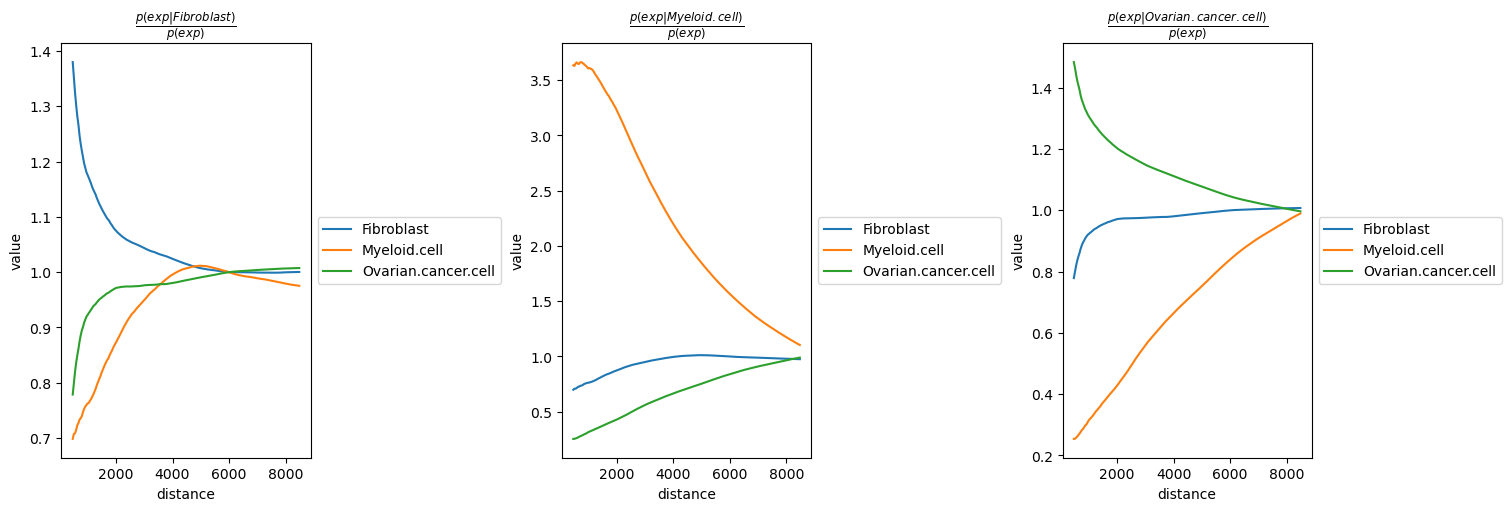

In [ ]:
# tiny subset just to confirm it runs
adata_test = adata_sub[:].copy()
sq.gr.co_occurrence(
    adata_test,
    cluster_key="cell_type",
    interval=200,
    n_splits=None,
    n_jobs=2,
    show_progress_bar=False,  # ignore bar
)
sq.pl.co_occurrence(adata_test, cluster_key="cell_type")

### Ripley’s L: quantifying spatial clustering of cell types

To assess whether each **cell type** forms clustered, random, or regularly spaced patterns across spatial scales, we used **Ripley’s L function** on a downsampled subset of cells.

**Logic of the statistic.**  
Ripley’s K function $K(r)$ measures, for a given radius $r$, the **expected number of points within distance $r$ of an arbitrary point**, normalized by the overall point density. Under **complete spatial randomness (CSR)** in 2D, $K(r) = \pi r^2$. The **L function** is a variance‑stabilized version:

$$
\hat{L}(r) = \sqrt{\frac{\hat{K}(r)}{\pi}}.
$$


Under CSR, $\hat{L}(r) \approx r$., so **steeper or higher $L(r)$ curves indicate stronger clustering** (more neighbors than expected) at the corresponding distances. Flatter, lower curves indicate a more diffuse or nearly random pattern.

`sq.pl.ripley` plots $L(r)$ versus distance for each **cell_type**, so we can directly compare how strongly different cell types cluster. In our data, **ovarian cancer cells and fibroblasts show higher $L(r)$ curves than myeloid cells across the sampled distances, indicating stronger spatial clustering of tumor and fibroblast niches compared to more diffusely distributed myeloid cells.** [web:278][web:324]

ERROR: Unable to fetch palette, reason: 'cell_type_colors'. Using `None`.


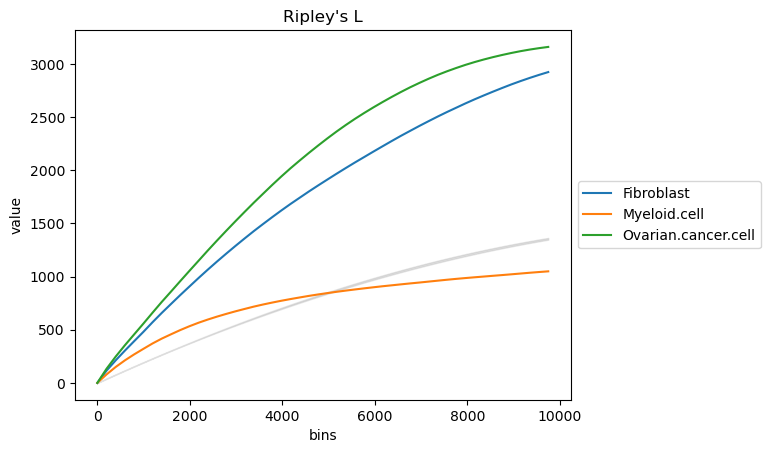

In [13]:
# compute Ripley’s L (variance‑stabilized K), usually the most interpretable
sq.gr.ripley(
    adata_test,
    cluster_key="cell_type",
    mode="L",              # 'F', 'G', or 'L'; L ≈ K-based clustering measure
    spatial_key="spatial", # or your key in .obsm
    n_simulations=100,     # permutation sims for confidence bands
)

sq.pl.ripley(
    adata_test,
    cluster_key="cell_type",
    mode="L",
)

In [30]:
diffexp_df = pd.read_csv(differential_expression_path)
diffexp_df


,Feature ID,Feature Name,Cluster 1 Mean Counts,Cluster 1 Log2 fold change,Cluster 1 Adjusted p value,Cluster 2 Mean Counts,Cluster 2 Log2 fold change,Cluster 2 Adjusted p value,Cluster 3 Mean Counts,Cluster 3 Log2 fold change,Cluster 3 Adjusted p value,Cluster 4 Mean Counts,Cluster 4 Log2 fold change,Cluster 4 Adjusted p value,Cluster 5 Mean Counts,Cluster 5 Log2 fold change,Cluster 5 Adjusted p value
0,ENSG00000238009,ENSG00000238009,0.000042,2.171718,2.305574e-01,0.000000,-1.211420,5.090305e-01,0.000000,2.440397,1.000000,0.000000,0.879356,1.000000,0.000000,3.031347,1.0
1,ENSG00000291215,ENSG00000291215,0.000727,1.912074,1.077689e-06,0.000121,-2.211420,1.110393e-05,0.000000,-1.680619,0.805163,0.000501,0.237810,1.000000,0.000000,-1.089669,1.0
2,ENSG00000237491,LINC01409,0.000083,0.019715,1.000000e+00,0.000121,0.940583,4.765922e-01,0.000000,0.762325,1.000000,0.000000,-0.798716,0.768209,0.000000,1.353275,1.0
3,ENSG00000290784,ENSG00000290784,0.000010,-0.735173,7.495938e-01,0.000017,0.525546,1.000000e+00,0.000000,2.762325,1.000000,0.000056,2.616322,0.593622,0.000000,3.353275,1.0
4,ENSG00000177757,FAM87B,0.000000,-1.150210,6.267450e-01,0.000000,0.110508,1.000000e+00,0.000154,5.762325,0.605730,0.000000,2.201284,1.000000,0.000000,4.353275,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22771,ENSG00000273748,ENSG00000273748,0.000042,-0.828282,5.466988e-01,0.000086,0.888116,5.409140e-01,0.000000,1.177362,1.000000,0.000056,0.741853,1.000000,0.000229,2.893843,1.0
22772,ENSG00000271254,ENSG00000271254,0.000073,1.264827,3.199077e-01,0.000017,-1.059417,5.043690e-01,0.000000,1.440397,1.000000,0.000056,1.031359,0.996609,0.000000,2.031347,1.0
22773,ENSG00000276345,ENSG00000276345,0.000031,0.264827,1.000000e+00,0.000035,0.695471,8.475932e-01,0.000000,2.177362,1.000000,0.000000,0.616322,1.000000,0.000000,2.768312,1.0
22774,ENSG00000273554,ENSG00000273554,0.000706,3.636386,1.148400e-12,0.000035,-3.454276,6.193221e-08,0.000307,0.197540,1.000000,0.000000,-2.988540,0.014041,0.000000,-0.836550,1.0


In [31]:
# Example: column names – adapt to your real ones
# "Feature Name" is your gene symbol or Ensembl ID
# "Cluster 1 Log2 fold change", "Cluster 1 Adjusted p value", etc.

marker_genes = []

for k in range(1, 6):  # clusters 1..5
    lfc_col = f"Cluster {k} Log2 fold change"
    p_col   = f"Cluster {k} Adjusted p value"
    
    df_k = diffexp_df[
        (diffexp_df[p_col] < 0.05) &
        (diffexp_df[lfc_col] > 0)
    ].copy()
    
    # sort by effect size, take top 20
    df_k = df_k.sort_values(lfc_col, ascending=False).head(20)
    
    genes_k = df_k["Feature Name"].tolist()  # or "Feature ID" if that matches adata.var_names
    marker_genes.extend(genes_k)

marker_genes = list(set(marker_genes))
print("Number of selected markers:", len(marker_genes))

Number of selected markers: 100


In [32]:
# Optionally keep raw counts
adata.raw = adata.copy()

# Normalize & log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

c:\Users\tesni\miniconda3\envs\ovarian-st\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


### Moran’s I: spatial autocorrelation of CD9 and CD55

We next asked whether key genes show **non‑random spatial patterns** (e.g. higher expression in specific niches) using **Moran’s I**, a global spatial autocorrelation statistic implemented in Squidpy


**Logic of the statistic.**  
For each gene, Moran’s I measures whether **similar expression values tend to occur at nearby locations** more than expected by chance: 

- $I > 0$: nearby spots have **similar expression** → **spatial clustering** of high/low values.  
- $I = 0$: pattern compatible with **spatial randomness**.  
- $I < 0$: nearby spots tend to be **dissimilar** → **spatial dispersion** or checkerboard patterns.  

Squidpy stores the results (Moran’s I, p‑values, etc.) in `adata_test.uns["moranI"]`, allowing us to quantify which genes are spatially structured.

To **visualize where** these genes are expressed in the tissue, we overlay their expression on spatial coordinates:

These scatter plots show **expression intensity in physical space**, so together with Moran’s I we can report, for example, that **CD9 and CD55 exhibit significantly positive spatial autocorrelation, with expression concentrated in specific tumor or stromal regions rather than randomly distributed across the section.** 

CD9 True
CD55 True
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 100/100 [00:07<00:00, 13.64/s]


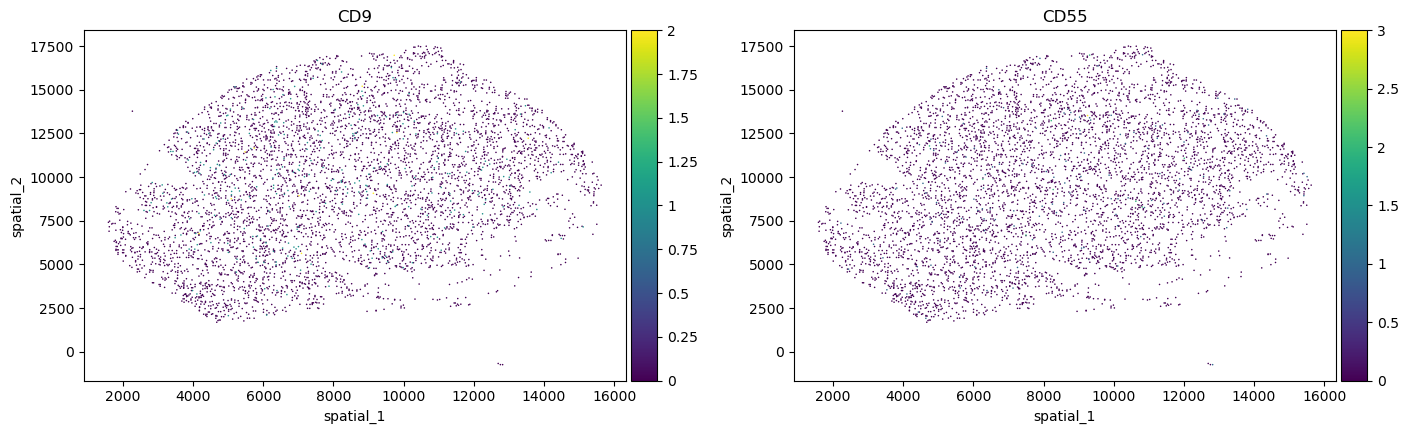

In [19]:
# 1. Make sure cell IDs and gene names are unique
adata_test.obs_names_make_unique()
adata_test.var_names_make_unique()

# 2. Check that the genes you want actually exist in var_names
for g in ["CD9", "CD55"]:
    print(g, g in adata_test.var_names)

# 3. Recompute neighbors (once) and Moran's I
sq.gr.spatial_neighbors(adata_test, coord_type="generic")

sq.gr.spatial_autocorr(
    adata_test,
    mode="moran",
    genes=["CD9", "CD55"],
    use_raw=False,          # be explicit: work on adata.X
    n_perms=100,
    n_jobs=4,
)

adata_test.obs[["spatial_1", "spatial_2"]] = adata_test.obsm["spatial"]
sc.pl.scatter(
    adata_test,
    x="spatial_1",
    y="spatial_2",
    color=["CD9", "CD55"],
    size=5
)

In [33]:
# 1. Make sure cell IDs and gene names are unique
adata.obs_names_make_unique()
adata.var_names_make_unique()

# 2. Check that the genes you want actually exist in var_names
for g in marker_genes:
    print(g, g in adata.var_names)

# 3. Recompute neighbors (once) and Moran's I
sq.gr.spatial_neighbors(adata, coord_type="generic")

sq.gr.spatial_autocorr(
    adata,
    mode="moran",
    genes=marker_genes,
    use_raw=False,          # be explicit: work on adata.X
    n_perms=100,
    n_jobs=4,
)

adata.obs[["spatial_1", "spatial_2"]] = adata.obsm["spatial"]
sc.pl.scatter(
    adata,
    x="spatial_1",
    y="spatial_2",
    color=marker_genes,
    size=5
)

LIPN True
VWDE True
ROBO4 True
APLN True
LINC02228 True
ECSCR True
IGHG3 True
GABRB2 True
ZNF750 True
ENSG00000260476 True
SHISA3 True
CLDN5 True
ARG1 True
ENSG00000271659 True
ENSG00000287778 True
TSPYL2 True
EMCN True
SMCO2 True
IGHG1 True
APELA True
HBA1 True
ESAM True
FNDC1-AS1 True
BHLHE22 True
ACKR4 True
CSMD3 True
OSM True
EBF2 True
MT3 True
FGR True
NOVA2 True
NRSN2-AS1 True
FCN1 True
HAPLN1 True
IGHGP True
OVOL1 True
MYCT1 True
HIF1A-AS3 True
FOXD1 True
ENSG00000291105 True
SORCS1 True
IGKC True
PRSS35 True
DIPK2B True
TRPV6 True
ENSG00000272732 True
SIRPB2 True
PON3 True
CRYBB2P1 True
LINC00539 True
NEGR1 True
SCN3A True
ZNF365 True
TFAP2E True
ASPA True
ENSG00000261335 True
GABRD True
VNN2 True
SYNPO True
ENSG00000274383 True
PXDNL True
G0S2 True
LINC02432 True
ENSG00000228835 True
ENSG00000258314 True
ANPEP True
GIPC3 True
ENSG00000285618 True
CLEC14A True
GOLT1A True
KMO True
PON1 True
FAM162B True
LINC01641 True
ADGRL4 True
MIR223HG True
CASKIN1 True
FBP1 True
ENSG0000028

KeyError: 'Spatial basis `spatial` not found in `adata.obsm`.'

**Logic of the method.**  
For each candidate **ligand–receptor pair** and each **source → target cell-type pair** (e.g. Fibroblast → Ovarian.cancer.cell), Squidpy:

1. Computes the **mean expression** of ligand in the source and receptor in the target.  
2. Performs a **permutation test** by shuffling cell-type labels `n_perms` times to build a null distribution.  
3. Derives **p‑values** for each LR–cell-type combination, marking interactions whose observed co‑expression is stronger than expected by chance.

The results are stored as LR **mean expression** and **p‑value** tables in `adata_sub.uns["ligrec"]`, and `sq.pl.ligrec` summarizes them as a **heatmap**:

- **Rows/columns:** source and target **cell types** (e.g. tumor, fibroblast, myeloid, endothelial).  
- **Color intensity:** strength/mean of the LR interaction, filtered by `means_range` and `pvalue_threshold`.  

This allows us to highlight, for example, **enriched fibroblast → tumor or myeloid → tumor ligand–receptor pairs**, supporting specific hypotheses about **paracrine signaling and immune–stromal crosstalk** in the ovarian cancer microenvironment.

In [21]:
for g in ["EPCAM", "COL11A1", "CD274"]:
    print(g, g in adata_sub.var_names)

EPCAM True
COL11A1 True
CD274 True


In [24]:


mg = mygene.MyGeneInfo()

# 1. Get Ensembl IDs (strip version suffixes like .1, .2, ...)
ensembl_ids = [g.split(".")[0] for g in adata_sub.var_names]

# 2. Query mygene: Ensembl gene IDs -> official symbols (human)
out = mg.querymany(
    ensembl_ids,
    scopes="ensembl.gene",
    fields="symbol",
    species="human"
)

# 3. Build mapping dict: original var_name -> symbol (or None if not found)
mapping = {}
for rec, original in zip(out, adata_sub.var_names):
    sym = rec.get("symbol")
    mapping[original] = sym if sym is not None else None

# 4. Store symbols in var['gene_symbols']
adata_sub.var["gene_symbols"] = adata_sub.var_names.map(mapping)

# Quick sanity check
print(adata_sub.var[["gene_symbols"]].head())
print("Mapped symbols:", adata_sub.var["gene_symbols"].notna().sum(), "/", adata_sub.n_vars)

INFO:biothings.client:querying 1-1000 ...


INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-19000 ...
INFO:biothings.client:querying 19001-20000 ...
INFO:biothings.client:querying 20001-21000 ...
INFO:biothings.client:querying 21001-22000 ...
INFO:biothings.client:querying

                gene_symbols
DDX11L2                 None
MIR1302-2HG             None
FAM138A                 None
ENSG00000290826         None
OR4F5                   None
Mapped symbols: 2002 / 38606


In [25]:
sq.gr.ligrec(
    adata_sub,
    cluster_key="cell_type",
    gene_symbols="gene_symbols",  # <--- use mapped symbols
    use_raw=False,
    n_perms=100,
    n_jobs=4,
)

sq.pl.ligrec(
    adata_sub,
    cluster_key="cell_type",
    means_range=(0.1, 1.0),
    pvalue_threshold=0.05,
)

100%|██████████| 100/100 [00:24<00:00,  4.03permutation/s]
c:\Users\tesni\miniconda3\envs\ovarian-st\Lib\site-packages\squidpy\pl\_ligrec.py:248: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
  if cluster_key not in adata.uns_keys():


ValueError: After removing rows with only NaN interactions, none remain.